# House Prices
## Linear Regression Pipeline

### 1. Load Libraries
* `mean_squared_error`, the mean of all the residuals squared

- `r2_score`- Measures how well your regression model explains the variance in the target variable
    - sees how well my model captures the natuarl variations that I am trying to predict

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


#### 1. Load Data

In [3]:
train = pd.read_csv('datasets/train.csv')
print(train.shape)
print(train.head())

(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008  

In [4]:
# 2. Basic Exploration
print(train.info())
print(train.describe())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
# Check missing values
missing = train.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64


### 3. Target Variable


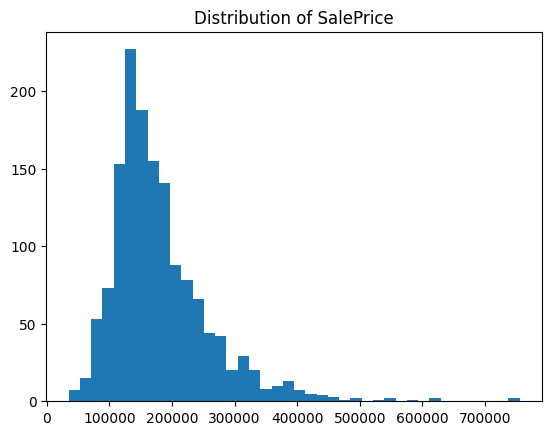

In [6]:
# numeric summary of where prices concentrate
y = train["SalePrice"]

plt.hist(y, bins=40)
plt.title("Distribution of SalePrice")
plt.show()

### 4. Simple Feature Selection (Numeric only)

This is to decide what information the model will use to predict house priceses. 

We defineed:
* X = features (inputs)
* Y = target (output)

Before in `Target Varible` we defined y and let it equal to train["SalePrice"] so y (the target) is the SalePrice column of the dataset

Why Numeric?
* Data set has both numbers and categories and linear regression can only understand nuimber values

`SalePrice was dropped in order to actually train X, if we kept it inside it would just be giving the model the answer`

Why fill missing values with the median?
* Most Modells don't handle NaN valllues so we replace it with median:
* we choose median:
    * More robust to outliers
    * House prices adn sizes are skewed distributions
    * Mean would get distorted by extreme mansions

In [7]:
numeric_features = train.select_dtypes(include=[np.number])

# Drop target from features
X = numeric_features.drop("SalePrice", axis=1)

# Fill issing values with median (simple approach for now)
X = X.fillna(X.median())



### 5. Train/Test Split
Basically we are simulating the future with this:

We say:
* 80% --> Train the model
* 20% --> Pretend this is "new unseen data"

if we train and test on the same data then the model doesnt learn it memorizes.

``This step helps protect against overfitting.``

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 6. Scaling
`Very important`
#### Why Scale?
If we pay attention to the feature ranges:
* LotArea could be up to 10,000
* OverAll Qual could be 1 to 10
* YearBuilt: 1900-2010

If we don't scale then the features with larger ranges could greatly effect the regression coefficients.

Scaling puts things to `Mean = 0` and `Std Dev = 1` so each feature competes fairly.

#### Why fit on train only.
If we fit on the whole dataset the we are leaking test information into the training which would be bad. This phenomenon is callled data leakage.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training the Model
`The Math`
This step finds the best line (or hyperplane) that predicts SalePrice from the features.

In [10]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 8. Evaluation
`Testing on unseen data`
Average squared prediction error.

Lower = better.

R²

How much variance in house prices we explained.
* 0 → useless model
* 1 → perfect prediction
* ~0.7–0.9 → strong model

In [11]:
#Evaluate
y_pred = model.predict(X_test_scaled)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))



MSE: 1360121073.2179818
R²: 0.8226775450640491


### Visualization
`Critical`
This will help see if the model was able to predict somewhat correctly

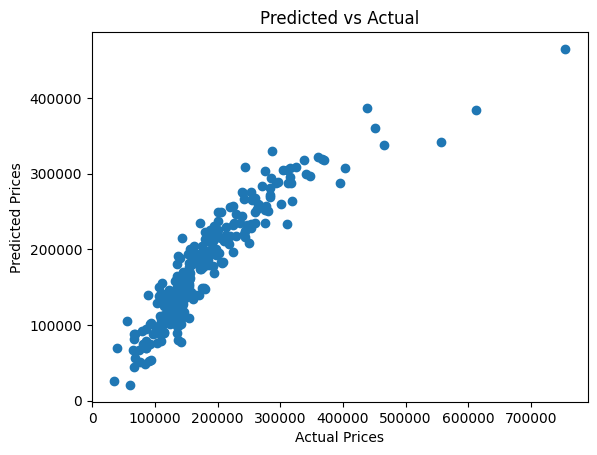

In [12]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual")
plt.show()